## Building a Customer Segmentation Model with K-Means Clustering

In [5]:
## Installing the required dependencies
%pip install numpy pandas scikit-learn matplotlib seaborn xgboost scipy kneed

Note: you may need to restart the kernel to use updated packages.


In [58]:
#show installed libraries

import numpy, pandas, matplotlib, seaborn, sklearn, kneed, scipy


print('numpy:', numpy.__version__)
print('pandas:', pandas.__version__)
print('matplotlib:', matplotlib.__version__)
print('seaborn:', seaborn.__version__)
print('scikit-learn:', sklearn.__version__)
print('kneed:', kneed.__version__)
print('scipy:', scipy.__version__)

numpy: 1.26.4
pandas: 2.2.3
matplotlib: 3.9.2
seaborn: 0.13.2
scikit-learn: 1.5.1
kneed: 0.8.5
scipy: 1.13.1


In [1]:
# Importing the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Understanding the data

In [2]:
data = pd.read_csv('customer_data.csv', encoding='unicode_escape')
data.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
data.shape

(541909, 8)

In [4]:
# Find the missing values in the dataset
data.isnull().sum().sum()

136534

In [5]:
# Dropping rows with missing CustomerID
data.dropna(subset=['CustomerID'], inplace=True)

# Removing rows with negative or zero quantity
data = data[data['Quantity'] > 0]

In [6]:
# removing rows where 'InvoiceNo' contains 'C' (indicating cancellations)
data = data[~data['InvoiceNo'].str.contains('C', na=False)]


In [7]:
# converting the 'InvoiceDate' column to datetime format
data['Date'] = pd.to_datetime(data['InvoiceDate'])

In [8]:
# remove duplicate
print(data.duplicated().sum())
data.drop_duplicates(inplace=True)

5192


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  object        
 1   StockCode    392732 non-null  object        
 2   Description  392732 non-null  object        
 3   Quantity     392732 non-null  int64         
 4   InvoiceDate  392732 non-null  object        
 5   UnitPrice    392732 non-null  float64       
 6   CustomerID   392732 non-null  float64       
 7   Country      392732 non-null  object        
 8   Date         392732 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 30.0+ MB


In [11]:
# calculating total price for each transaction
data["TotalPrice"] = data["Quantity"] * data["UnitPrice"]

data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Date,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,2010-12-01 08:26:00,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,2010-12-01 08:26:00,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,20.34


The informative features in this dataset that tell us about customer buying behavior include “Quantity”, “InvoiceDate” and “UnitPrice.” Using these variables, we are going to derive a customer’s RFM profile - Recency, Frequency, Monetary Value.

RFM is commonly used in marketing to evaluate a client’s value based on their:

Recency: How recently have they made a purchase?
Frequency: How often have they bought something?
Monetary Value: How much money do they spend on average when making purchases?

With the variables in this e-commerce transaction dataset, we will calculate each customer’s recency, frequency, and monetary value. These RFM values will then be used to build the segmentation model.

#### a. Calculating Recency

In [12]:
# keeping only the most recent purchase date for each customer
data['rank'] = data.sort_values(['CustomerID','Date']).groupby(['CustomerID'])['Date'].rank(method='min').astype(int)

data_rec = data[data['rank']==1]

In [14]:
# assign recency score to each customerID
data_rec['recency'] = (data_rec['Date'] - pd.to_datetime(min(data_rec['Date']))).dt.days

C:\Users\venkatanarayana\AppData\Local\Temp\ipykernel_63684\4056498615.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_rec['recency'] = (data_rec['Date'] - pd.to_datetime(min(data_rec['Date']))).dt.days


In [16]:
data_rec.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Date,TotalPrice,rank,recency
541801,581578,22993,SET OF 4 PANTRY JELLY MOULDS,12,12/9/2011 12:16,1.25,12713.0,Germany,2011-12-09 12:16:00,15.00,1,373
541802,581578,22907,PACK OF 20 NAPKINS PANTRY DESIGN,12,12/9/2011 12:16,0.85,12713.0,Germany,2011-12-09 12:16:00,10.20,1,373
541803,581578,22908,PACK OF 20 NAPKINS RED APPLES,12,12/9/2011 12:16,0.85,12713.0,Germany,2011-12-09 12:16:00,10.20,1,373
541804,581578,23215,JINGLE BELL HEART ANTIQUE SILVER,12,12/9/2011 12:16,2.08,12713.0,Germany,2011-12-09 12:16:00,24.96,1,373
541805,581578,22736,RIBBON REEL MAKING SNOWMEN,10,12/9/2011 12:16,1.65,12713.0,Germany,2011-12-09 12:16:00,16.50,1,373


#### b. Calculating Frequency

In [20]:
freq = data_rec.groupby('CustomerID')['Date'].count()
data_freq = pd.DataFrame(freq).reset_index()
data_freq.columns = ['CustomerID','frequency']

data_freq.head()

,CustomerID,frequency
0,12346.0,1
1,12347.0,31
2,12348.0,17
3,12349.0,73
4,12350.0,17


In [22]:
rec_freq = data_freq.merge(data_rec,on='CustomerID')

rec_freq.head()

,CustomerID,frequency,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country,Date,TotalPrice,rank,recency
0,12346.0,1,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1/18/2011 10:01,1.04,United Kingdom,2011-01-18 10:01:00,77183.6,1,48
1,12347.0,31,537626,85116,BLACK CANDELABRA T-LIGHT HOLDER,12,12/7/2010 14:57,2.10,Iceland,2010-12-07 14:57:00,25.2,1,6
2,12347.0,31,537626,22375,AIRLINE BAG VINTAGE JET SET BROWN,4,12/7/2010 14:57,4.25,Iceland,2010-12-07 14:57:00,17.0,1,6
3,12347.0,31,537626,71477,COLOUR GLASS. STAR T-LIGHT HOLDER,12,12/7/2010 14:57,3.25,Iceland,2010-12-07 14:57:00,39.0,1,6
4,12347.0,31,537626,22492,MINI PAINT SET VINTAGE,36,12/7/2010 14:57,0.65,Iceland,2010-12-07 14:57:00,23.4,1,6


#### c. Calculating Monetary Value

In [23]:
rec_freq['total'] = rec_freq['Quantity']*data['UnitPrice']
m = rec_freq.groupby('CustomerID')['total'].sum()
m = pd.DataFrame(m).reset_index()
m.columns = ['CustomerID','monetary_value']

In [24]:
# merging monetary_value with rec_freq
rfm = m.merge(rec_freq,on='CustomerID')
rfm.head()

,CustomerID,monetary_value,frequency,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country,Date,TotalPrice,rank,recency,total
0,12346.0,189248.25,1,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1/18/2011 10:01,1.04,United Kingdom,2011-01-18 10:01:00,77183.6,1,48,189248.25
1,12347.0,1246.73,31,537626,85116,BLACK CANDELABRA T-LIGHT HOLDER,12,12/7/2010 14:57,2.10,Iceland,2010-12-07 14:57:00,25.2,1,6,40.68
2,12347.0,1246.73,31,537626,22375,AIRLINE BAG VINTAGE JET SET BROWN,4,12/7/2010 14:57,4.25,Iceland,2010-12-07 14:57:00,17.0,1,6,11.00
3,12347.0,1246.73,31,537626,71477,COLOUR GLASS. STAR T-LIGHT HOLDER,12,12/7/2010 14:57,3.25,Iceland,2010-12-07 14:57:00,39.0,1,6,40.68
4,12347.0,1246.73,31,537626,22492,MINI PAINT SET VINTAGE,36,12/7/2010 14:57,0.65,Iceland,2010-12-07 14:57:00,23.4,1,6,122.04


In [26]:
# Finally, let's select columns for our Customer Segmentation model
final_rfm = rfm[['CustomerID','recency','frequency','monetary_value']]
final_rfm.head()

,CustomerID,recency,frequency,monetary_value
0,12346.0,48,1,189248.25
1,12347.0,6,31,1246.73
2,12347.0,6,31,1246.73
3,12347.0,6,31,1246.73
4,12347.0,6,31,1246.73


recency: 


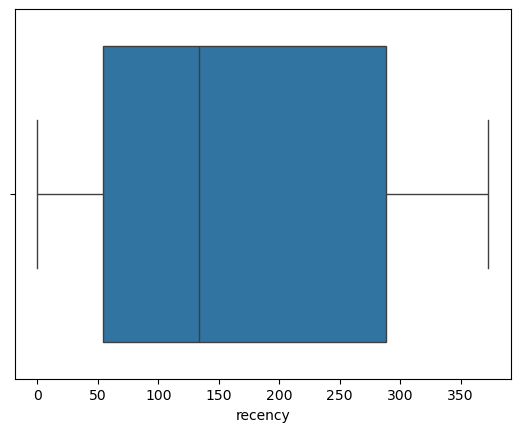

frequency: 


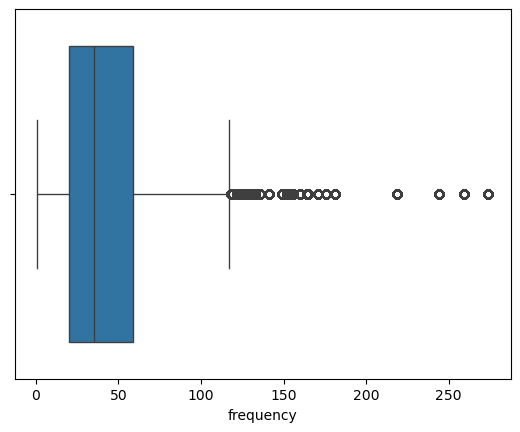

monetary_value: 


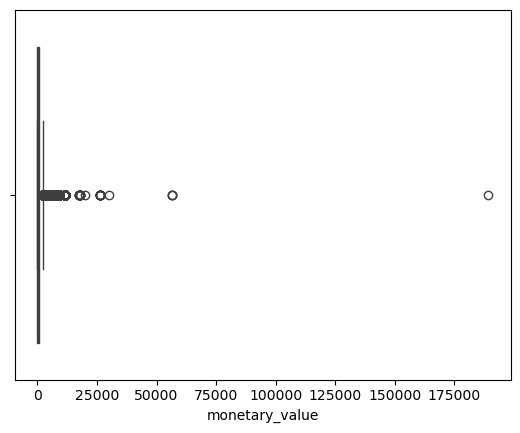

In [27]:
# Visualize the distribution of recency, frequency, and monetary_value
list1 = ['recency','frequency','monetary_value']
for i in list1:
    print(str(i)+': ')
    ax = sns.boxplot(x=final_rfm[str(i)])
    plt.show()

We can clearly see that there are many outliers in columns frequency and monetary_value. So, we will use Z-Score metric to remove the outliers. Z-Scores tell us how far away from the mean a data point is. A Z-Score of 3, for instance, means that a value is 3 standard deviations away from the variable’s mean.

In [28]:
from scipy import stats

# remove the customer id column
new_df = final_rfm[['recency','frequency','monetary_value']]

# remove outliers
z_scores = stats.zscore(new_df)
abs_z_scores = np.abs(z_scores)
filtered_entries = (abs_z_scores < 3).all(axis=1)
new_df = new_df[filtered_entries]

In [35]:
new_df.head()

,recency,frequency,monetary_value
1,6,31,1246.73
2,6,31,1246.73
3,6,31,1246.73
4,6,31,1246.73
5,6,31,1246.73


In [36]:
# Applying standardization to scale the dataset’s values so that they follow a normal distribution
from sklearn.preprocessing import StandardScaler
new_df = new_df.drop_duplicates()
col_names = ['recency', 'frequency', 'monetary_value']
features = new_df[col_names]
scaler = StandardScaler().fit(features.values)
features = scaler.transform(features.values)
scaled_features = pd.DataFrame(features, columns = col_names)

In [37]:
scaled_features.head()

,recency,frequency,monetary_value
0,-1.238620,0.362601,1.346799
1,-1.162059,-0.299375,6.333463
2,1.730227,2.348529,1.952128
3,-0.753736,-0.299375,0.218590
4,-0.634642,-0.393943,0.323296


### Finally, let's apply K-Means Clustering to build the Customer Segmentation Model

Text(0, 0.5, 'Inertia')

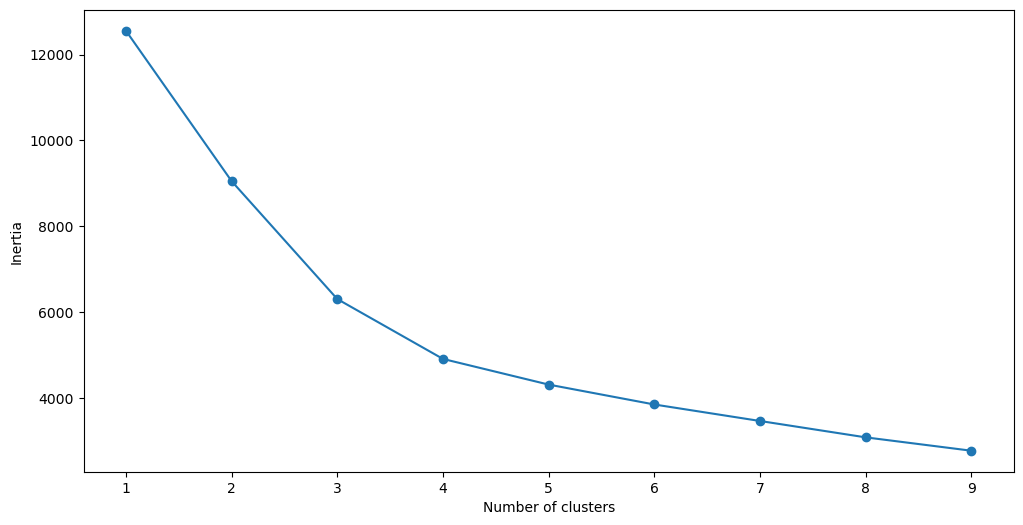

In [38]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
SSE = []
for cluster in range(1,10):
    kmeans = KMeans(n_clusters = cluster, init='k-means++')
    kmeans.fit(scaled_features)
    SSE.append(kmeans.inertia_)
# converting the results into a dataframe and plotting them
frame = pd.DataFrame({'Cluster':range(1,10), 'SSE':SSE})
plt.figure(figsize=(12,6))
plt.plot(frame['Cluster'], frame['SSE'], marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

The “elbow” of this graph is the point of inflection on the curve, and in this case is at the 4-cluster mark. This means that the optimal number of clusters to use in this K-Means algorithm is 4. 
Let’s now build the model with 4 clusters.

In [39]:
# First, build a model with 4 clusters
kmeans = KMeans( n_clusters = 4, init='k-means++')
kmeans.fit(scaled_features)

KMeans(n_clusters=4)

To evaluate the performance of this model, we will use a metric called the silhouette score. This is a coefficient value that ranges from -1 to +1. A higher silhouette score is indicative of a better model.

In [40]:
print(silhouette_score(scaled_features, kmeans.labels_, metric='euclidean'))

0.3967309562405137


Now that we have built our segmentation model, we need to assign clusters to each customer in the dataset

In [41]:
pred = kmeans.predict(scaled_features)
frame = pd.DataFrame(new_df)
frame['cluster'] = pred

In [42]:
frame.head()

,recency,frequency,monetary_value,cluster
1,6,31,1246.73,2
32,15,17,4311.90,2
49,355,73,1618.81,3
122,63,17,553.25,0
139,77,15,617.61,0


### Let's visualize the data to identify the distinct traits of customers in each segment

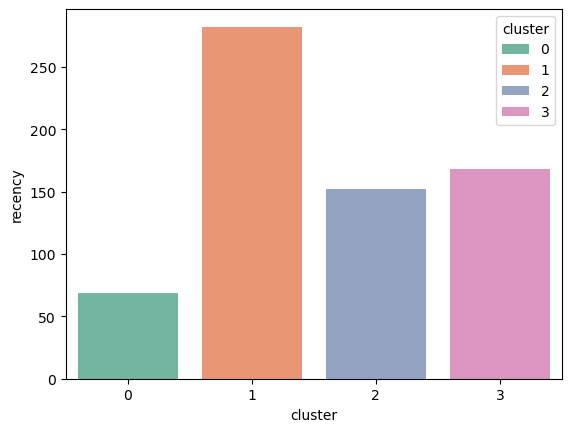

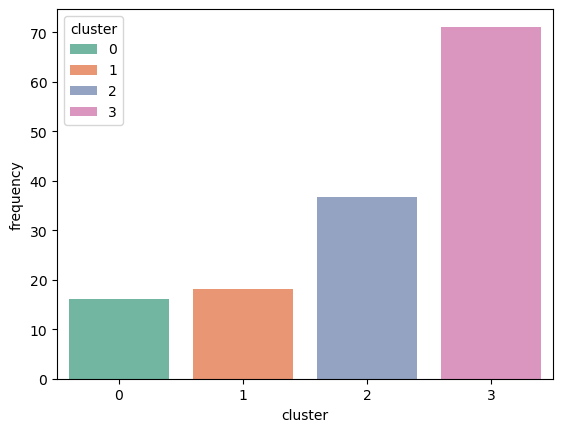

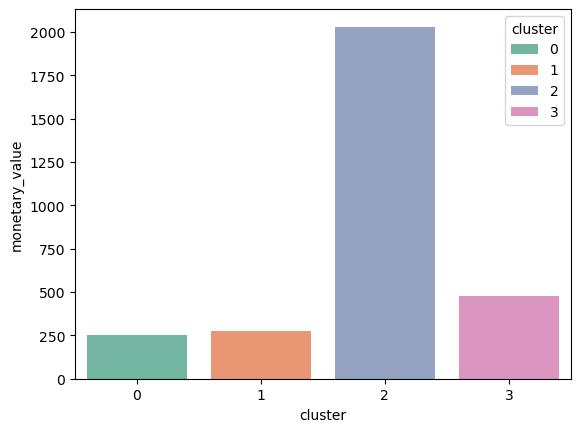

In [48]:
avg_df = frame.groupby(['cluster'], as_index=False).mean()
for i in list1:
    sns.barplot(x='cluster',y=str(i),data=avg_df, palette='Set2', hue='cluster')
    plt.show()

## Interpretation of Results:

1. Cluster 2 represents the most valuable customers with high purchase frequency and exceptionally high monetary value, indicating that they contribute the largest share of revenue. Although their recency is moderate, they remain actively engaged and should be prioritized for retention through loyalty programs and exclusive offers.

2. Cluster 3 consists of highly active customers with the highest purchase frequency and strong recent engagement, but with only moderate monetary value. This segment presents strong upselling and cross-selling opportunities to increase their average transaction value.

3. Cluster 0 includes customers with relatively recent purchases but low frequency and low spending, suggesting occasional or potentially new buyers who require nurturing strategies to encourage repeat purchases. 

4. Finally, Cluster 1 comprises customers with the highest recency (longest time since last purchase), low purchase frequency, and low monetary value, indicating an at-risk or dormant segment that may benefit from targeted re-engagement campaigns.

All in all, the segmentation highlights that Cluster 2 drives revenue, Cluster 3 drives engagement, Cluster 0 holds growth potential, and Cluster 1 requires reactivation efforts.

In [ ]:
# Save the model using pickle
import pickle

filename = 'customer_segmentation_model.pkl'

with open(filename, 'wb') as file:
    pickle.dump(kmeans, file)

file.close()

pickle.dump(kmeans, open('customer_segmentation_model.pkl', 'wb'))


In [50]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", scaler),
    ("kmeans", kmeans)
])

with open("customer_segmentation_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline, f)